<a href="https://colab.research.google.com/github/NatalieAleksandrova2026/DTA_2026/blob/main/ML/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [3]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()

,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


In [4]:
df.shape

(1000, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       1000 non-null   float64
 1   rooms      1000 non-null   int64  
 2   floor      1000 non-null   int64  
 3   dist_km    1000 non-null   float64
 4   age_years  1000 non-null   int64  
 5   price      1000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


In [7]:
print(f'Table size: {df.shape[0]} rows x {df.shape[1]} columns')
print('/nIs there any missing spaces?')
print(df.isna().sum())
df.describe().round(2)

Table size: 1000 rows x 6 columns
/nIs there any missing spaces?
area         0
rooms        0
floor        0
dist_km      0
age_years    0
price        0
dtype: int64


,area,rooms,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,2.48,12.69,4.96,30.39,136.25
std,19.33,0.95,7.00,4.71,17.23,44.99
min,20.00,1.00,1.00,0.30,0.00,20.00
25%,47.08,2.00,6.00,1.50,16.00,104.15
50%,60.50,2.00,13.00,3.60,30.00,136.75
75%,73.00,3.00,19.00,7.00,45.25,165.45
max,137.10,5.00,24.00,25.00,59.00,282.40


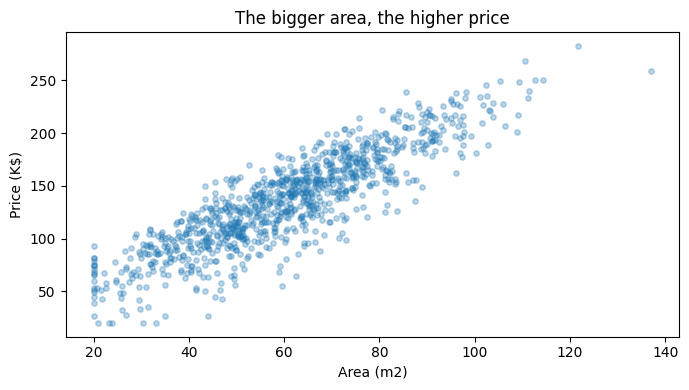

In [13]:
plt.figure(figsize=(7,4))
plt.scatter(df['area'], df['price'], alpha=0.3, s=15)
plt.xlabel('Area (m2)')
plt.ylabel('Price (K$)')
plt.title('The bigger area, the higher price')
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X = df[['area', 'rooms', 'floor', 'dist_km', 'age_years']] #features
y = df['price'] #target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Studying print: ", X_train.shape[0], "flats")
print("Testing print: ", X_test.shape[0], "flats")

Studying print:  800 flats
Testing print:  200 flats


In [14]:
df.columns

Index(['area', 'rooms', 'floor', 'dist_km', 'age_years', 'price'], dtype='object')

## Linea Regression

In [21]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    'real_price': y_test[:5].round(2),
    'predict_price': y_pred[:5].round(2)
})

compare['error'] = (compare['predict_price'] - compare['real_price']).round(2)
compare

,real_price,predict_price,error
521,119.1,129.69,10.59
737,173.3,178.26,4.96
740,20.0,26.36,6.36
660,93.7,110.87,17.17
411,100.6,97.21,-3.39


##MAE - mean average error  
##RMSE

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE = {mae:.1f} K $ error in average')
print(f"MSE = {mse:.1f}")
print(f'RMSE = {rmse:.1f} K $')
print(f'R2 = {r2:.3f} (the model shows {r2 * 100:.1f}% price shift)')


MAE = 8.7 K $ error in average
MSE = 117.3
RMSE = 10.8 K $
R2 = 0.947 (the model shows 94.7% price shift)


In [36]:
coefs = pd.DataFrame({
    'features': X.columns,
    'coef': model.coef_.round(2)

}).sort_values('coef', key=abs, ascending=False)



print(f'Basic price: {model.intercept_:.2F} K $/n')
print('How those features infuence the price')

coefs

Basic price: 40.83 K $/n
How those features infuence the price


,features,coef
1,rooms,5.22
3,dist_km,-3.07
0,area,1.78
4,age_years,-0.49
2,floor,0.39


In [37]:
price2 = (
    40.83
    + area * 1.78
    + rooms * 5.22
    + dist_km * (-3.07)
    + age_years	* (-0.49)
    + floor	* 0.39
)